In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(project_root)

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import importlib
import model as md
import view as vw

import glob
import re

importlib.reload(md)
importlib.reload(vw)

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>

In [2]:
# ==========================================
# ОБРАБОТКА ВСЕХ ПАПОК
# ==========================================

import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt


def extract_index(filename):
    match = re.search(r"\((\d+)\)", filename)
    if match:
        return int(match.group(1))
    return 0


def sort_files(file_list):
    return sorted(
        file_list,
        key=lambda x: extract_index(os.path.basename(x))
    )


root_dir = os.path.join(project_root, "data", "bio")

all_frel = {}
all_impedance = {}

for subdir, dirs, files in os.walk(root_dir):

    chan1_files = glob.glob(
        os.path.join(subdir, "RTB2004_CHAN1*.csv")
    )

    chan2_files = glob.glob(
        os.path.join(subdir, "RTB2004_CHAN2*.csv")
    )

    if not chan1_files or not chan2_files:
        continue

    chan1_files = sort_files(chan1_files)
    chan2_files = sort_files(chan2_files)

    frel_list = []
    impedance_list = []

    print("\n==========================")
    print("Папка:", os.path.basename(subdir))
    print("==========================")

    for f1, f2 in zip(chan1_files, chan2_files):

        t, U = md.make_real_data_list(f1)
        t, I = md.make_real_data_list(f2)

        # поиск рабочей частоты
        F, V = md.get_spectrum3(t, U)
        F_peak_calc = F[np.argmax(V)]

        # фильтрация
        t_f, U_f = md.filter_butter_bandpass(
            t, U,
            F_peak_calc,
            200e3,
            2
        )

        t_f, I_f = md.filter_butter_bandpass(
            t, I,
            F_peak_calc,
            200e3,
            2
        )

        # частота релаксации
        phase_fft = md.get_phase_SWFR(
            t_f,
            I_f,
            U_f,
            F_peak_calc
        )

        f_rel = phase_fft#md.get_F_rel(
        #    phase_fft,
        #    F_peak_calc
        #)

        # импеданс через спектр
        FU, SU = md.get_spectrum3(t_f, U_f)
        FI, SI = md.get_spectrum3(t_f, I_f)

        idx = np.argmin(
            np.abs(FU - F_peak_calc)
        )

        Z = SU[idx] / SI[idx]

        frel_list.append(f_rel)
        impedance_list.append(Z)

        print(
            f"{os.path.basename(f1)} | "
            f"Frel = {f_rel:.3f} | "
            f"Z = {Z:.3f}"
        )

    folder_name = os.path.basename(subdir)

    all_frel[folder_name] = np.array(frel_list)
    all_impedance[folder_name] = np.array(impedance_list)

print("\nГотово.")


Папка: Измерение 10 четверть
RTB2004_CHAN1.CSV | Frel = 27.206 | Z = 330.453
RTB2004_CHAN1(1).CSV | Frel = 25.248 | Z = 262.176
RTB2004_CHAN1(2).CSV | Frel = 24.469 | Z = 265.066
RTB2004_CHAN1(3).CSV | Frel = 23.720 | Z = 278.880
RTB2004_CHAN1(4).CSV | Frel = 56.308 | Z = 6520.289
RTB2004_CHAN1(5).CSV | Frel = 58.027 | Z = 5935.450
RTB2004_CHAN1(6).CSV | Frel = 57.899 | Z = 6029.748
RTB2004_CHAN1(7).CSV | Frel = 59.798 | Z = 6236.674

Папка: Измерение 11 3 четвертых
RTB2004_CHAN1.CSV | Frel = 27.191 | Z = 339.561
RTB2004_CHAN1(1).CSV | Frel = 25.621 | Z = 267.318
RTB2004_CHAN1(2).CSV | Frel = 24.591 | Z = 242.260
RTB2004_CHAN1(3).CSV | Frel = 23.728 | Z = 231.595
RTB2004_CHAN1(4).CSV | Frel = 23.085 | Z = 222.850
RTB2004_CHAN1(5).CSV | Frel = 22.683 | Z = 225.492
RTB2004_CHAN1(6).CSV | Frel = 22.581 | Z = 219.620
RTB2004_CHAN1(7).CSV | Frel = 22.197 | Z = 221.618
RTB2004_CHAN1(8).CSV | Frel = 21.877 | Z = 225.715
RTB2004_CHAN1(9).CSV | Frel = 22.513 | Z = 299.392
RTB2004_CHAN1(10).CSV

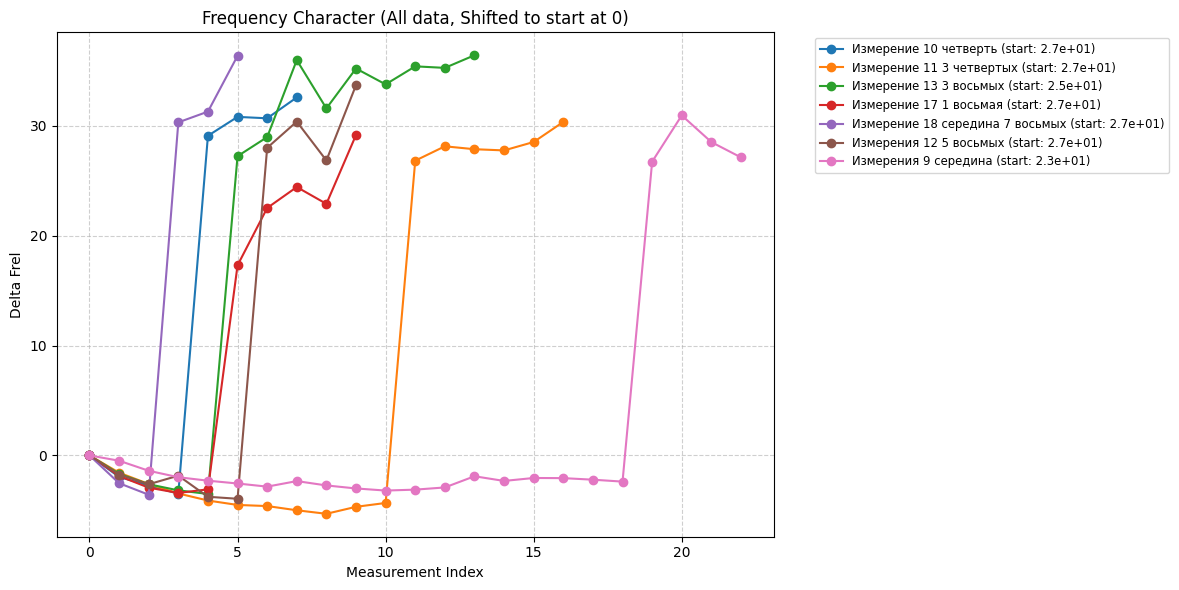

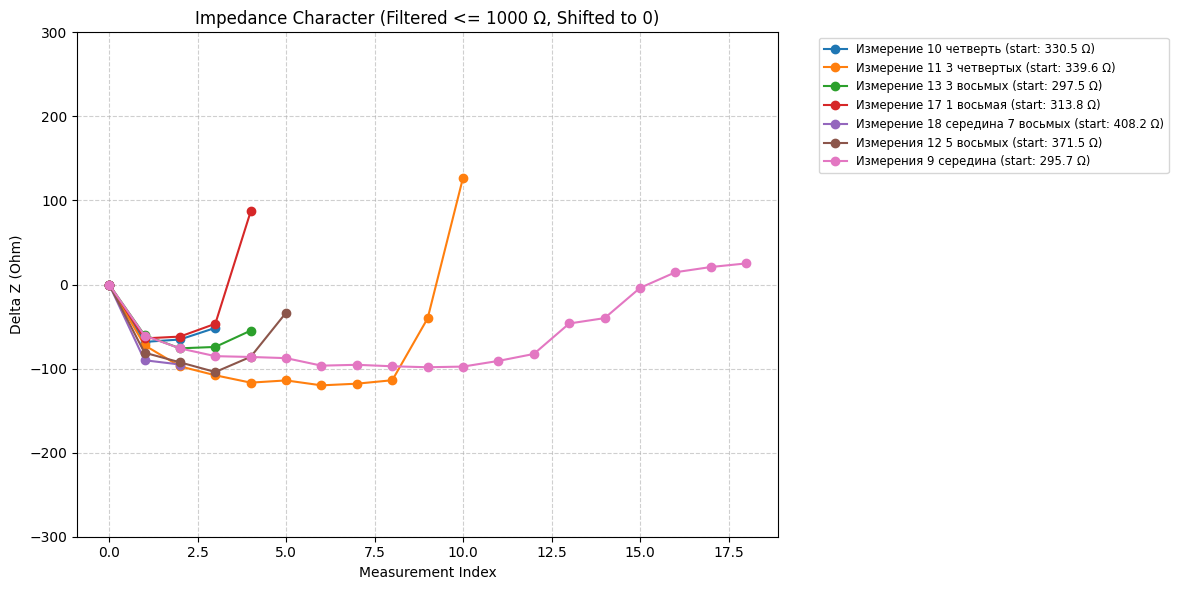

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры фильтрации
Z_THRESHOLD = 1000

# ---------- Частота релаксации (ВСЕ данные, сдвиг к 0) ----------
plt.figure(figsize=(12, 6))

for folder, f_values in all_frel.items():
    f_array = np.array(f_values)
    
    if len(f_array) > 0:
        # Берем самое первое значение для сдвига (без фильтрации)
        f_start = f_array[0]
        f_shifted = f_array - f_start
        
        plt.plot(
            f_shifted,
            marker='o',
            label=f"{folder} (start: {f_start:.1e})"
        )

plt.title("Frequency Character (All data, Shifted to start at 0)")
plt.xlabel("Measurement Index")
plt.ylabel("Delta Frel")

# ВАЖНО: На ваших данных есть огромные выбросы (минус 1.5 миллиона).
# Чтобы увидеть "характер" основной массы кривых, раскомментируйте строку ниже:
# plt.ylim(-5e5, 5e5) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()


# ---------- Импеданс (Фильтр <= 1000, сдвиг к 0) ----------
plt.figure(figsize=(12, 6))

for folder, z_values in all_impedance.items():
    # Применяем фильтр только для импеданса
    z_filtered = np.array([z if z <= Z_THRESHOLD else np.nan for z in z_values])
    
    # Находим первую валидную точку для сдвига
    valid_indices = np.where(~np.isnan(z_filtered))[0]
    if len(valid_indices) > 0:
        z_start = z_filtered[valid_indices[0]]
        z_shifted = z_filtered - z_start
        
        plt.plot(
            z_shifted,
            marker='o',
            label=f"{folder} (start: {z_start:.1f} Ω)"
        )

plt.title(f"Impedance Character (Filtered <= {Z_THRESHOLD} Ω, Shifted to 0)")
plt.xlabel("Measurement Index")
plt.ylabel("Delta Z (Ohm)")

# Ограничиваем масштаб, чтобы видеть форму кривых
plt.ylim(-300, 300) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()